# 📊 Bank Loan Analysis

A professional exploratory data analysis (EDA) of a bank loan dataset — cleaning the data, then visualizing loan status, grade, purpose, income, and risk patterns to surface insights useful for credit-risk decision making.

## 📚 Import Libraries & Load Dataset
Load the required Python libraries and read in the loan dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_excel("financial_loan.xlsx")
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [2]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


## 🔍 Dataset Overview
Inspect the structure, size, and column types of the dataset.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

## 🧹 Data Cleaning
Check for missing values across all columns.

In [4]:
df.isnull().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

### Handling Missing Values
Fill missing `emp_title` values using the mode within each `emp_length` group, then confirm column data types.

In [5]:
df["emp_title"]=df.groupby("emp_length")["emp_title"].transform(lambda x: x.fillna(x.mode().iloc[0]))
df["emp_title"].isnull().sum()

np.int64(0)

In [6]:
df["emp_title"].value_counts()

emp_title
Bank of America                    847
US Army                            644
Kaiser Permanente                  169
Self Employed                      118
IBM                                 67
                                  ... 
Joseph M Sanzari Company             1
Swat Fame                            1
Anaheim Regional Medical Center      1
Brooklyn Radiology                   1
Allen Edmonds                        1
Name: count, Length: 28525, dtype: int64

In [7]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

### Total Loan Applications
Count the total number of loan applications in the dataset.

In [8]:
total_loan_application=df["id"].count()

print("total loan application are:",total_loan_application)



total loan application are: 38576


## 📈 Exploratory Data Analysis
### Loan Status Analysis
Visualize the distribution of loan statuses (fully paid, current, charged off).

C:\Users\asus\AppData\Local\Temp\ipykernel_9580\3433268396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x="loan_status",palette="Set2")


Text(0.5, 1.0, 'Loan Status Analysis')

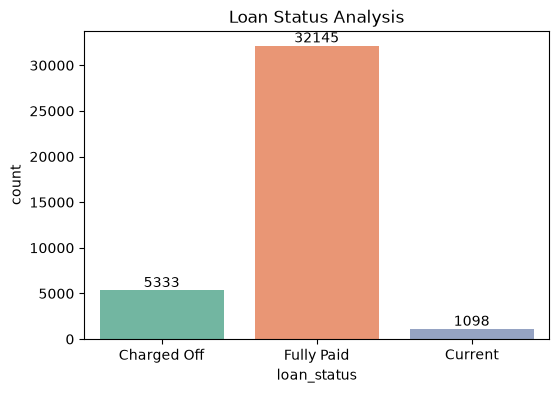

In [9]:
plt.figure(figsize=(6,4))
ax=sns.countplot(data=df,x="loan_status",palette="Set2")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])

plt.title("Loan Status Analysis")

### Loan Grade Analysis
Visualize how many loans fall into each credit grade (A–G).

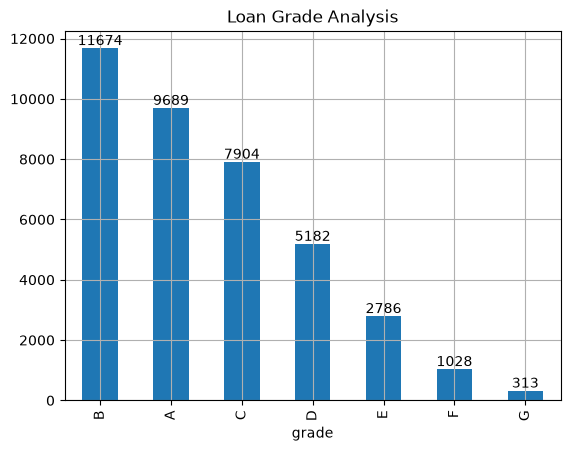

In [10]:
ax=df["grade"].value_counts().plot(kind="bar")
ax.bar_label(ax.containers[0])

plt.title("Loan Grade Analysis")
plt.grid(True)


### Home Ownership Distribution
Visualize the distribution of home ownership status among applicants.

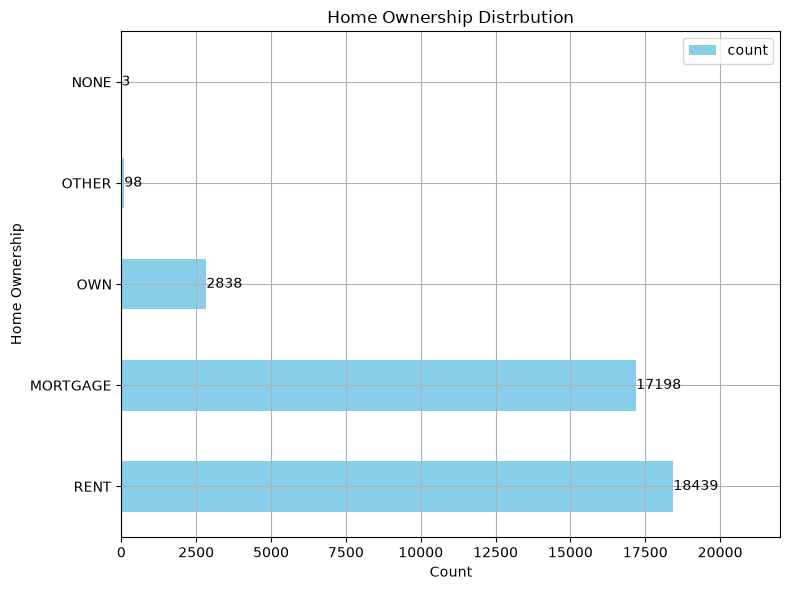

In [11]:
plt.figure(figsize=(8,6))
count=df["home_ownership"].value_counts()
ax=count.plot(kind="barh",color="skyblue")
ax.bar_label(ax.containers[0])

plt.xlim(0,22000)
plt.ylabel("Home Ownership")
plt.xlabel("Count")
plt.title("Home Ownership Distrbution")
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()


### Verification Status Analysis
Visualize how applicant income verification status is distributed.

C:\Users\asus\AppData\Local\Temp\ipykernel_9580\1701655055.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x="verification_status",palette="Set3")


[Text(0, 0, '12335')]

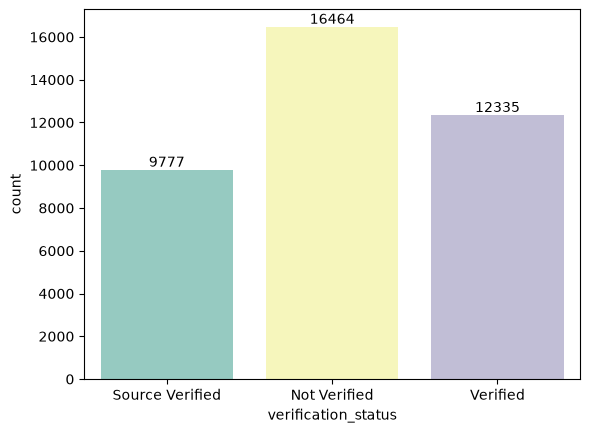

In [12]:
ax=sns.countplot(data=df,x="verification_status",palette="Set3")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])


### Purpose for Taking a Loan
Visualize the most common reasons applicants take out loans.

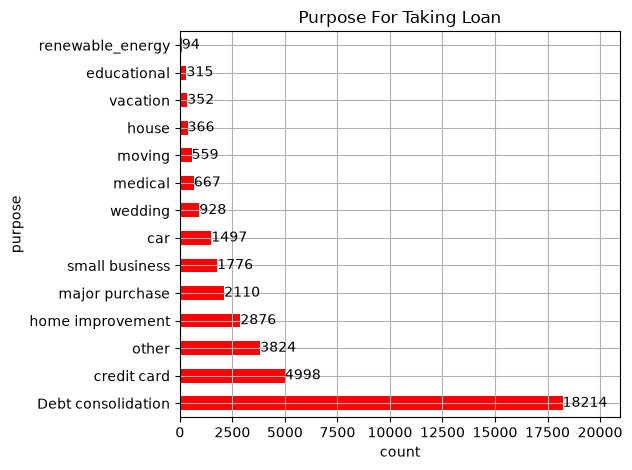

In [13]:
count=df["purpose"].value_counts()
ax=count.plot(kind="barh",color="red")
plt.xlim(0,count.max()*1.15)
ax.bar_label(ax.containers[0])
plt.xlabel("count")
plt.title("Purpose For Taking Loan")
plt.grid(True)
plt.tight_layout()

**Insight:** Debt consolidation is the most common purpose for taking a loan.

### Loan Amount vs Annual Income
Examine the relationship between loan amount and applicant annual income.

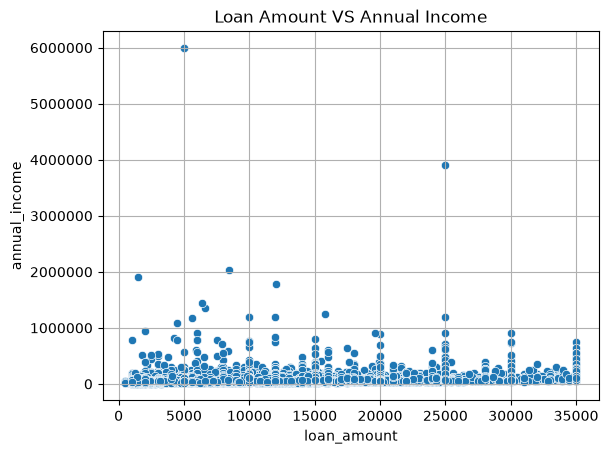

In [14]:
sns.scatterplot(
    data=df,
    x="loan_amount",
    y="annual_income"
)
plt.title("Loan Amount VS Annual Income")
plt.ticklabel_format(style="plain",axis="y")
plt.grid(True)

**Insight:** Most applicants have an annual income below $100K, with high-income applicants (above $100K) relatively rare — indicating most loan takers come from low- or middle-income groups.

### Loan Amount by Grade
Compare the distribution of loan amounts across different credit grades.

C:\Users\asus\AppData\Local\Temp\ipykernel_9580\1948661641.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'Loan amount comparision across different grade')

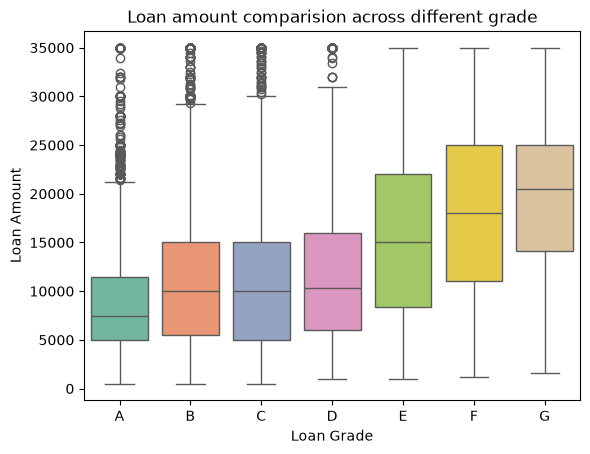

In [15]:
order=["A","B","C","D","E","F","G"]
sns.boxplot(
    data=df,
    x="grade",
    y="loan_amount",
    order=order,
    palette="Set2"
)
plt.xlabel("Loan Grade")
plt.ylabel("Loan Amount")
plt.title("Loan amount comparision across different grade")

### Loan Applications by Month
Count how many loan applications were issued in each calendar month.

In [16]:
month=df.groupby(df["issue_date"].dt.month_name())["id"].count()
month

issue_date
April        2755
August       3441
December     4314
February     2279
January      2332
July         3366
June         3184
March        2627
May          2911
November     4035
October      3796
September    3536
Name: id, dtype: int64

### Monthly Trend Visualization
Plot the monthly loan application counts in calendar order.

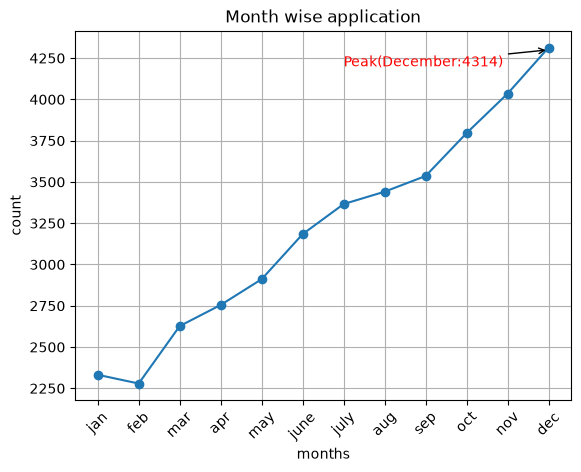

In [17]:
order=["January","February","March","April","May","June","July","August","September","October","November","December"]
month=df.groupby(df["issue_date"].dt.month_name())["id"].count()
month=month.reindex(order)
labels=["jan","feb","mar","apr","may","june","july","aug","sep","oct","nov","dec"]

month.index=labels

fig,ax=plt.subplots()
month.plot(kind="line",marker="o",ax=ax)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels,rotation=45)
plt.title("Month wise application")
plt.ylabel("count")
plt.xlabel("months")
plt.annotate(
    "Peak(December:4314)",
    xy=(11,4300),
    xytext=(6,4200),
    arrowprops=dict(arrowstyle="->",color="black"),
    fontsize=10,
    color="red"
)
plt.grid(True)

**Insight:** The majority of loan applications were submitted in December.

### Risk Segmentation
Compare loan status against grade, home ownership, term, and other factors to identify patterns in credit risk.

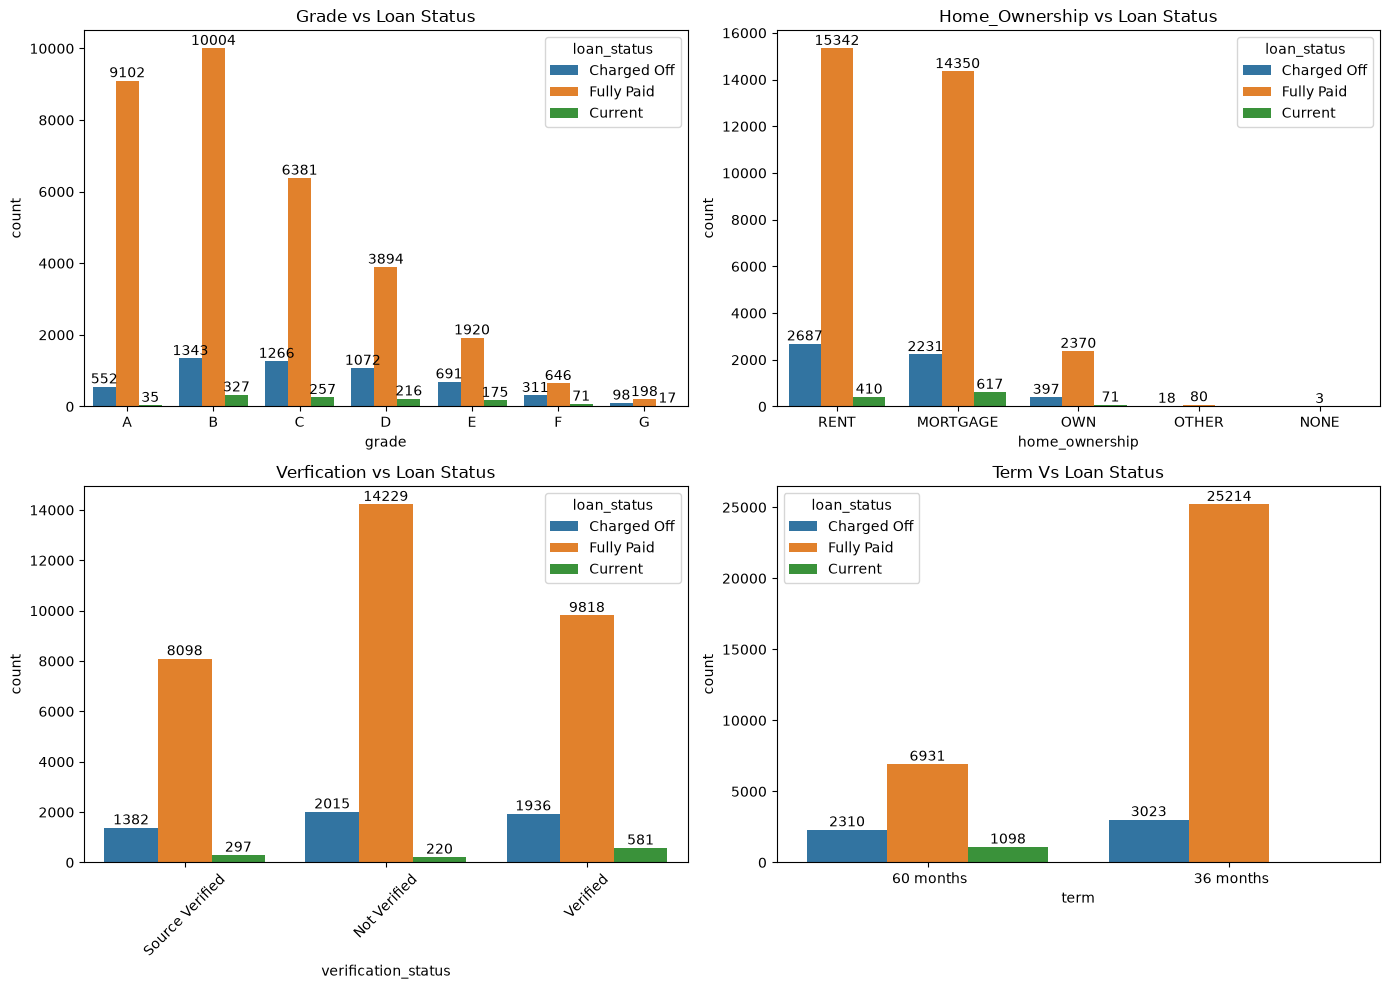

In [18]:
fig,ax=plt.subplots(2,2,figsize=(14,10))
sns.countplot(
    data=df,
    x="grade",
    hue="loan_status",
    ax=ax[0,0],
    order=["A","B","C","D","E","F","G"]
)
ax[0,0].set_title("Grade vs Loan Status")
sns.countplot(
    data=df,
    x="home_ownership",
    hue="loan_status",
    ax=ax[0,1]
)
ax[0,1].set_title("Home_Ownership vs Loan Status")
sns.countplot(
    data=df,
    x="verification_status",
    hue="loan_status",
    ax=ax[1,0],
    
)
ax[1,0].tick_params(rotation=45,axis="x")
ax[1,0].set_title("Verfication vs Loan Status")
sns.countplot(
    data=df,
    x="term",
    hue="loan_status",
    ax=ax[1,1]
)
ax[1,1].set_title("Term Vs Loan Status")



for a in ax.flat:
    for container in a.containers:
        a.bar_label(container)
plt.tight_layout()
plt.show()



**Insight:** A low-risk loan applicant is typically classified as Grade A or B, opting for a 36-month term, and holding rent or mortgage status — this segment shows the strongest repayment capability and the lowest probability of default.

### Installment Distribution
Visualize the distribution of monthly installment amounts, with the average marked.

Text(0.5, 1.0, 'Installment Distribution')

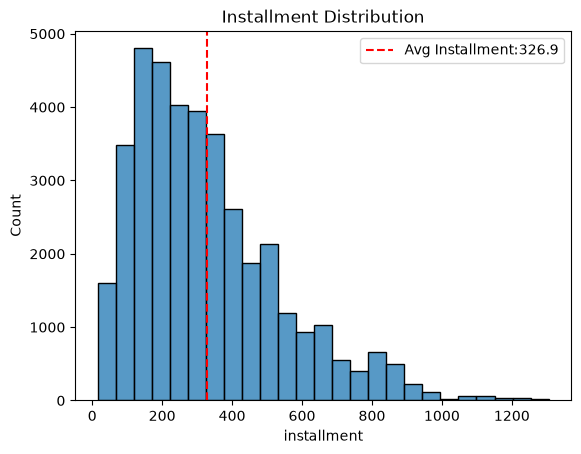

In [19]:
sns.histplot(df["installment"],bins=25)
plt.axvline(df["installment"].mean(),color="red",linestyle="--",label=f"Avg Installment:{df["installment"].mean():.1f}")
plt.legend()
plt.title("Installment Distribution")

### Interest Rate vs Loan Status
Compare interest rates across loan outcomes to see if higher rates correlate with default.

C:\Users\asus\AppData\Local\Temp\ipykernel_9580\3816999146.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="loan_status",y="int_rate",palette="Set2")


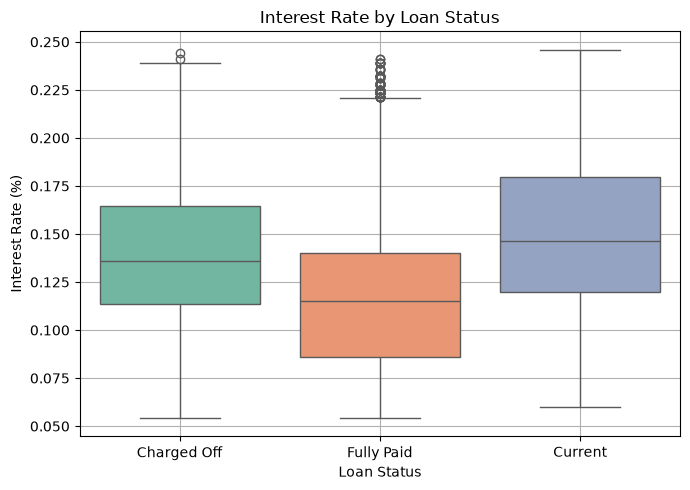

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="loan_status",y="int_rate",palette="Set2")
plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")
plt.grid(True)
plt.tight_layout()

### Debt-to-Income (DTI) Ratio vs Loan Status
Examine whether applicants with higher debt-to-income ratios are more likely to default.

C:\Users\asus\AppData\Local\Temp\ipykernel_9580\3258307072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="loan_status",y="dti",palette="Set3")


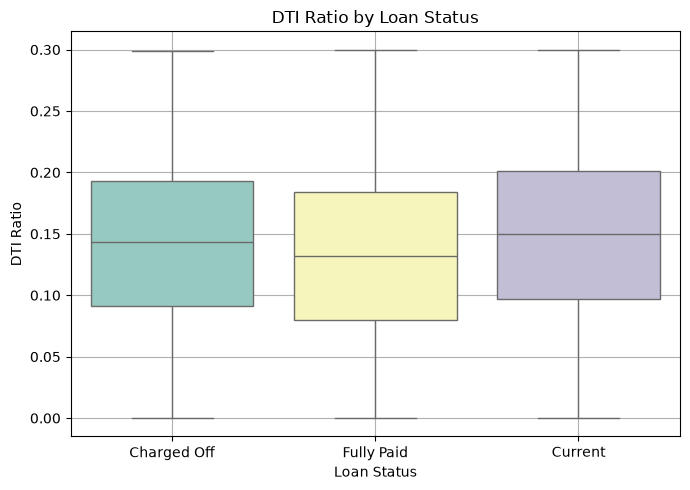

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="loan_status",y="dti",palette="Set3")
plt.title("DTI Ratio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("DTI Ratio")
plt.grid(True)
plt.tight_layout()

### Correlation Heatmap
Visualize correlations between key numeric variables to identify relationships useful for further modeling.

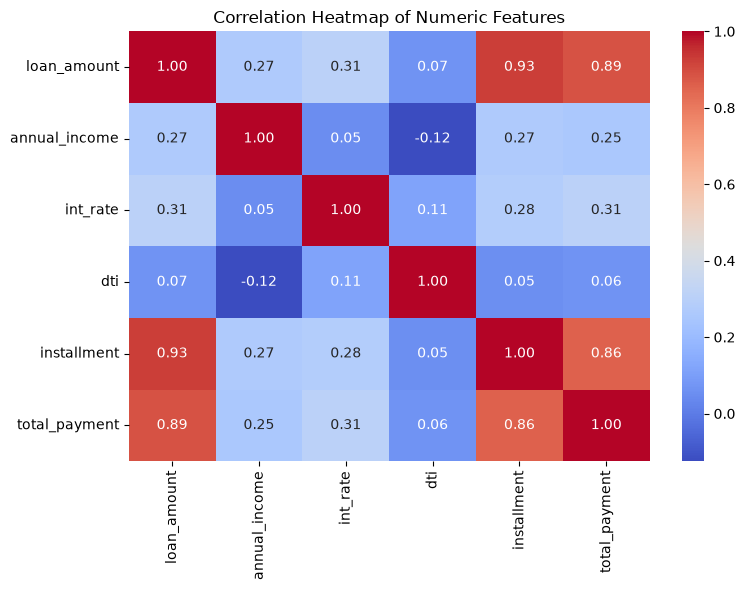

In [22]:
plt.figure(figsize=(8,6))
num_cols=["loan_amount","annual_income","int_rate","dti","installment","total_payment"]
corr=df[num_cols].corr()
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()

### Charge-Off Rate by Sub-Grade
Break grade down into sub-grades (A1–G5) to see a more granular view of default risk.

### Top 10 States by Loan Applications
Identify which states contribute the most loan applications.

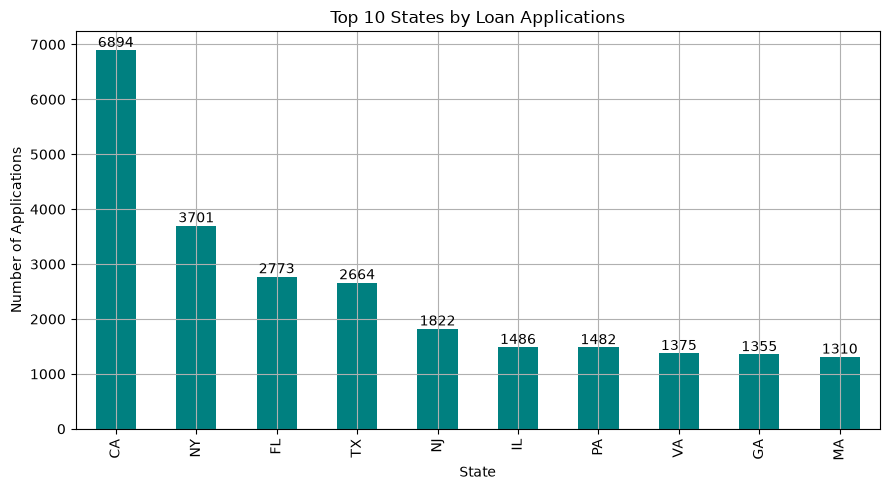

In [24]:
top_states=df["address_state"].value_counts().head(10)
plt.figure(figsize=(9,5))
ax=top_states.plot(kind="bar",color="teal")
ax.bar_label(ax.containers[0])
plt.title("Top 10 States by Loan Applications")
plt.xlabel("State")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()

### Loan Term vs Default Rate
Compare charge-off rates between 36-month and 60-month loan terms.

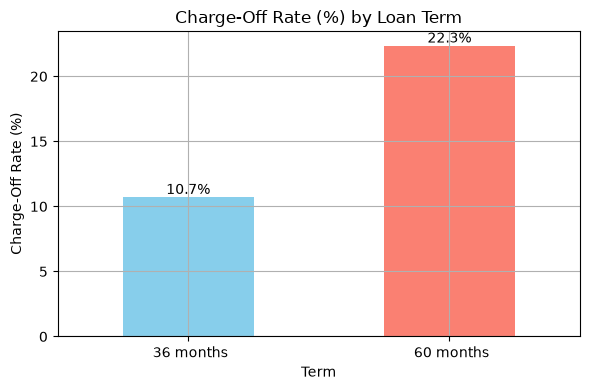

In [30]:
term_status=df.groupby("term")["loan_status"].apply(lambda x:(x=="Charged Off").mean()*100)
plt.figure(figsize=(6,4))
ax=term_status.plot(kind="bar",color=["skyblue","salmon"])
ax.bar_label(ax.containers[0],fmt="%1.1f%%")
plt.title("Charge-Off Rate (%) by Loan Term")
plt.xlabel("Term")
plt.ylabel("Charge-Off Rate (%)")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()

## 📌 Project Summary

This project performs an exploratory data analysis (EDA) on a bank loan dataset to identify trends, patterns, and relationships between financial variables. It covers data cleaning, handling missing values, descriptive statistics, and visualization to better understand the dataset.

Key visualizations explore distributions, detect relationships, and surface insights that support data-driven credit-risk decisions — such as the dominance of debt consolidation as a loan purpose, the income profile of typical applicants, seasonal application trends, and the characteristics of low-risk borrowers.

Overall, this analysis demonstrates practical skills in Python, Pandas, NumPy, Matplotlib, and Seaborn for real-world financial data analysis, and lays the groundwork for further predictive modeling or business intelligence applications.